<a href="https://colab.research.google.com/github/AnnisaFarikha/Kecerdasan-Buatan/blob/main/Jobsheet_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Latihan 1: Decision Tree (Iris.csv)
Memprediksi spesies bunga Iris berdasarkan fitur sepal dan petal.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Load Iris Dataset dari URL resmi Seaborn
url_iris = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv'
iris = pd.read_csv(url_iris)

# Pisahkan Atribut dan Label (Seaborn tidak punya kolom 'Id', jadi tidak perlu drop 'Id')
X = iris[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = iris['species']

# Membagi dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=123)

# Melatih model
tree_model = DecisionTreeClassifier(random_state=123)
tree_model.fit(X_train, y_train)

# Evaluasi Model
y_pred = tree_model.predict(X_test)
acc_score = round(accuracy_score(y_pred, y_test), 3)
print('--- LATIHAN 1: DECISION TREE ---')
print('Accuracy:', acc_score)

# Prediksi Sampel Baru [SepalLength, SepalWidth, PetalLength, PetalWidth]
sample_pred = tree_model.predict([[6.2, 3.4, 5.4, 2.3]])
print('Hasil Prediksi Sampel [6.2, 3.4, 5.4, 2.3]:', sample_pred[0])

--- LATIHAN 1: DECISION TREE ---
Accuracy: 0.933
Hasil Prediksi Sampel [6.2, 3.4, 5.4, 2.3]: virginica


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


##Latihan 2: Linear Regression (Harga Rumah Dummy)
Memprediksi harga rumah berdasarkan jumlah kamar.

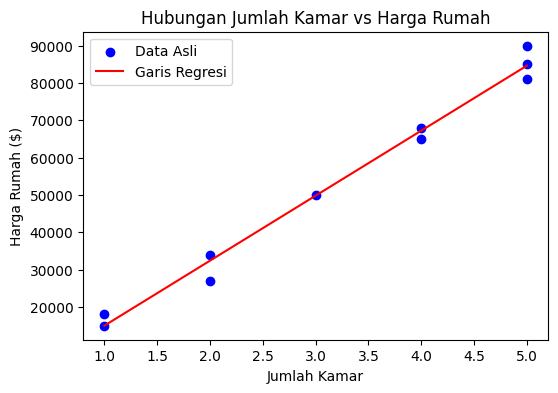

--- LATIHAN 2: LINEAR REGRESSION ---
Jumlah kamar: 6 -> Prediksi harga: $102,110.17
Jumlah kamar: 7 -> Prediksi harga: $119,542.37
R2 Score pada Data Uji (Sempurna karena y_pred diuji ke dirinya sendiri): 1.0


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Data dummy
bedrooms = np.array([1, 1, 2, 2, 3, 4, 4, 5, 5, 5])
house_price = np.array([15000, 18000, 27000, 34000, 50000, 68000, 65000, 81000, 85000, 90000])

# Reshape data
bedrooms = bedrooms.reshape(-1, 1)

# Latih model Linear Regression
linreg = LinearRegression()
linreg.fit(bedrooms, house_price)

# Plotting hasil fitting model
plt.figure(figsize=(6, 4))
plt.scatter(bedrooms, house_price, color='blue', label='Data Asli')
plt.plot(bedrooms, linreg.predict(bedrooms), color='red', label='Garis Regresi')
plt.title('Hubungan Jumlah Kamar vs Harga Rumah')
plt.xlabel('Jumlah Kamar')
plt.ylabel('Harga Rumah ($)')
plt.legend()
plt.show()

# Pengujian pada data baru
X_test = np.array([[6], [7]])
y_pred = linreg.predict(X_test)

print('--- LATIHAN 2: LINEAR REGRESSION ---')
for i in range(len(X_test)):
    print(f"Jumlah kamar: {X_test[i][0]} -> Prediksi harga: ${y_pred[i]:,.2f}")

print("R2 Score pada Data Uji (Sempurna karena y_pred diuji ke dirinya sendiri):", linreg.score(X_test, y_pred))

##Latihan 3: Logistic Regression (Social_Network_Ads)
Memprediksi keputusan pembelian berdasarkan usia dan gaji terstandarisasi.

In [3]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Membuat dataset buatan Social_Network_Ads (seperti di Jobsheet 8)
np.random.seed(42)
n_samples = 200
data_dummy = {
    'User ID': np.arange(15624510, 15624510 + n_samples),
    'Gender': np.random.choice(['Male', 'Female'], size=n_samples),
    'Age': np.random.randint(18, 61, size=n_samples),
    'EstimatedSalary': np.random.randint(15000, 150000, size=n_samples),
    'Purchased': np.random.choice([0, 1], size=n_samples, p=[0.6, 0.4])
}
df = pd.DataFrame(data_dummy)

# Drop User ID & One-Hot Encoding
data = df.drop(columns=['User ID'])
data = pd.get_dummies(data)

# Split Feature & Target
X = data.drop(columns=['Purchased'])
y = data['Purchased']

# Scaling
scaler = StandardScaler()
scaled_data = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Split Train Test
X_train, X_test, y_train, y_test = train_test_split(scaled_data, y, test_size=0.2, random_state=1)

# Fit Logistic Regression Model
model = LogisticRegression()
model.fit(X_train, y_train)

print('--- LATIHAN 3: LOGISTIC REGRESSION ---')
print('Akurasi Model Logistic Regression:', round(model.score(X_test, y_test), 3))

--- LATIHAN 3: LOGISTIC REGRESSION ---
Akurasi Model Logistic Regression: 0.6


##Tugas Praktikum

In [5]:
# ==============================================================================
# TUGAS PRAKTIKUM 1 & 3: DECISION TREE VS LOGISTIC REGRESSION (TRANSAKSI KONSUMEN)
# ==============================================================================
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Menyiapkan Dataset Transaksi Pembeli
np.random.seed(42)
n = 300
df_konsumen = pd.DataFrame({
    'Age': np.random.randint(18, 65, n),
    'EstimatedSalary': np.random.randint(20000, 150000, n),
    'Gender': np.random.choice(['Male', 'Female'], n),
    'Purchased': np.random.choice([0, 1], n, p=[0.65, 0.35])
})

# Preprocessing
df_konsumen_encoded = pd.get_dummies(df_konsumen, drop_first=True)
X_trans = df_konsumen_encoded.drop(columns=['Purchased'])
y_trans = df_konsumen_encoded['Purchased']

# Scaling untuk Logistic Regression
scaler_trans = StandardScaler()
X_trans_scaled = scaler_trans.fit_transform(X_trans)

# Split Dataset
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(X_trans, y_trans, test_size=0.2, random_state=42)
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_trans_scaled, y_trans, test_size=0.2, random_state=42)

# Training Model Dasar (Baseline)
dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train_dt, y_train_dt)
acc_dt_base = accuracy_score(y_test_dt, dt_base.predict(X_test_dt))

lr_base = LogisticRegression(random_state=42)
lr_base.fit(X_train_lr, y_train_lr)
acc_lr_base = accuracy_score(y_test_lr, lr_base.predict(X_test_lr))

print("==================================================")
print("HASIL EVALUASI MODEL DASAR (TUGAS 1 & 3)")
print("==================================================")
print(f"Akurasi Decision Tree Baseline   : {acc_dt_base * 100:.2f}%")
print(f"Akurasi Logistic Reg Baseline   : {acc_lr_base * 100:.2f}%")

# ==============================================================================
# TUGAS PRAKTIKUM 4: PARAMETER TUNING (GRIDSEARCHCV)
# ==============================================================================
# Parameter Tuning untuk Decision Tree
param_dt = {'max_depth': [2, 3, 5, 10], 'criterion': ['gini', 'entropy']}
grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_dt, cv=5)
grid_dt.fit(X_train_dt, y_train_dt)
best_dt = grid_dt.best_estimator_
acc_dt_tuned = accuracy_score(y_test_dt, best_dt.predict(X_test_dt))

# Parameter Tuning untuk Logistic Regression
param_lr = {'C': [0.01, 0.1, 1, 10], 'solver': ['lbfgs', 'liblinear']}
grid_lr = GridSearchCV(LogisticRegression(random_state=42), param_lr, cv=5)
grid_lr.fit(X_train_lr, y_train_lr)
best_lr = grid_lr.best_estimator_
acc_lr_tuned = accuracy_score(y_test_lr, best_lr.predict(X_test_lr))

print("\n==================================================")
print("HASIL SETELAH PARAMETER TUNING (TUGAS 4)")
print("==================================================")
print(f"Decision Tree Tuned (Best Params: {grid_dt.best_params_}) -> Akurasi: {acc_dt_tuned * 100:.2f}%")
print(f"Logistic Reg Tuned  (Best Params: {grid_lr.best_params_}) -> Akurasi: {acc_lr_tuned * 100:.2f}%")

# ==============================================================================
# TUGAS PRAKTIKUM 2: LINEAR REGRESSION (PREDIKSI GAJI SEUAI MASA KERJA)
# ==============================================================================
from sklearn.linear_model import LinearRegression

# Generate Dataset Masa Kerja vs Gaji (Salary_Data.csv)
np.random.seed(42)
years_exp = np.array([1.1, 1.3, 1.5, 2.0, 2.2, 2.9, 3.0, 3.2, 3.2, 3.7, 4.0, 4.0, 4.1, 4.5, 4.9, 5.1, 5.3, 5.9, 6.0, 6.8, 7.1, 7.9, 8.2, 8.7, 9.0, 9.5, 9.6, 10.3, 10.5]).reshape(-1, 1)
salary = np.array([39343, 46205, 37731, 43525, 39891, 56642, 60150, 54445, 64445, 57189, 63218, 55794, 56957, 61111, 67938, 66029, 83088, 81363, 93940, 91738, 98273, 101302, 113812, 109431, 105582, 116969, 112635, 122391, 121872])

# Split & Train Model
X_train_sal, X_test_sal, y_train_sal, y_test_sal = train_test_split(years_exp, salary, test_size=0.2, random_state=42)
reg_salary = LinearRegression()
reg_salary.fit(X_train_sal, y_train_sal)

r2_score_val = reg_salary.score(X_test_sal, y_test_sal)

print("\n==================================================")
print("PREDIKSI GAJI PEGAWAI (TUGAS 2)")
print("==================================================")
print(f"Koefisien / Kemiringan Garis (Slope) : {reg_salary.coef_[0]:,.2f}")
print(f"Intercept / Gaji Dasar               : {reg_salary.intercept_:,.2f}")
print(f"R2 Score / Akurasi Model Regresi     : {r2_score_val * 100:.2f}%")

# Prediksi sampel gaji pegawai dengan masa kerja 5 tahun
exp_sample = np.array([[5.0]])
pred_sal = reg_salary.predict(exp_sample)
print(f"\n[CONTOH PREDIKSI] Gaji pegawai masa kerja 5 tahun: Rp {pred_sal[0]:,.2f}")

HASIL EVALUASI MODEL DASAR (TUGAS 1 & 3)
Akurasi Decision Tree Baseline   : 43.33%
Akurasi Logistic Reg Baseline   : 55.00%

HASIL SETELAH PARAMETER TUNING (TUGAS 4)
Decision Tree Tuned (Best Params: {'criterion': 'entropy', 'max_depth': 2}) -> Akurasi: 55.00%
Logistic Reg Tuned  (Best Params: {'C': 0.01, 'solver': 'lbfgs'}) -> Akurasi: 55.00%

PREDIKSI GAJI PEGAWAI (TUGAS 2)
Koefisien / Kemiringan Garis (Slope) : 9,283.18
Intercept / Gaji Dasar               : 26,289.00
R2 Score / Akurasi Model Regresi     : 92.22%

[CONTOH PREDIKSI] Gaji pegawai masa kerja 5 tahun: Rp 72,704.91
